In [1]:
import pandas as pd
import json

# 1. Carregar o JSON
with open('MC1_final_00.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

rounds_data = data['rounds']

# Listas para armazenar as linhas
tabela_rounds = []
tabela_messages = []
tabela_participants = []

# Iterar sobre cada round
for round_id, r in enumerate(rounds_data):
    # --- TABELA 1: ROUNDS (Contexto) ---
    context = r.get('environment_context', {})
    # Prevenção extra caso o context seja null
    if not isinstance(context, dict):
        context = {}
        
    market = context.get('market_snapshot', {})
    if not isinstance(market, dict):
        market = {}
    
    round_row = {
        'round_id': round_id,
        'hour': r.get('hour'),
        'event_narrative': context.get('event_narrative'),
        'event_headline': context.get('event_headline'),
        'stock_price': market.get('stock_price'),
        'percent_change': market.get('percent_change'),
        'market_sentiment': market.get('sentiment'),
        'social_state': context.get('social_state')
    }
    tabela_rounds.append(round_row)
    
    # --- TABELA 2: COMMUNICATIONS (Mensagens) ---
    for msg in r.get('communications', []):
        msg['round_id'] = round_id
        
        # CORREÇÃO AQUI: Pegamos o estado interno de forma segura
        internal_state = msg.get('internal_state')
        
        # Verificamos se ele não é None e se é de fato um dicionário
        if isinstance(internal_state, dict):
            msg['state_reacting'] = internal_state.get('reacting')
            msg['state_rationalizing'] = internal_state.get('rationalizing')
            msg['state_deliberating'] = internal_state.get('deliberating')
        else:
            # Se for nulo, preenchemos com nulo nas colunas novas também
            msg['state_reacting'] = None
            msg['state_rationalizing'] = None
            msg['state_deliberating'] = None
            
        # Limpa a coluna original aninhada (se ela existir)
        if 'internal_state' in msg:
            del msg['internal_state'] 
            
        tabela_messages.append(msg)
        
    # --- TABELA 3: PARTICIPANTS (Participantes) ---
    for p in r.get('participants', []):
        # Proteção caso agent_round_metadata venha como null também
        metadata = p.get('agent_round_metadata')
        if not isinstance(metadata, dict):
            metadata = {}
            
        participant_row = {
            'round_id': round_id,
            'agent_id': p.get('agent_id'),
            'agent_role': p.get('agent_role'),
            'declared_action': p.get('declared_action'),
            'sentiment_at_turn': metadata.get('sentiment_at_turn'),
            'action_classification': metadata.get('action_classification')
        }
        tabela_participants.append(participant_row)

# 2. Converter para DataFrames
df_rounds = pd.DataFrame(tabela_rounds)
df_messages = pd.DataFrame(tabela_messages)
df_participants = pd.DataFrame(tabela_participants)

# 3. Exportar para CSVs
df_rounds.to_csv('./data_rounds.csv', index=False)
df_messages.to_csv('./data_messages.csv', index=False)
df_participants.to_csv('./data_participants.csv', index=False)

print("Processamento concluído! Arquivos gerados com sucesso.")

Processamento concluído! Arquivos gerados com sucesso.


In [2]:
import pandas as pd

# 1. Carregando os dados
df_rounds = pd.read_csv('data_rounds.csv')
df_messages = pd.read_csv('data_messages.csv')
df_participants = pd.read_csv('data_participants.csv')

tabelas = {
    'Rounds': df_rounds,
    'Messages': df_messages,
    'Participants': df_participants
}

print("=== TÓPICO 1 e 2: ESTRUTURA DOS DADOS ===")
for nome, df in tabelas.items():
    print(f"\nTabela: {nome}")
    print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
    print("Tipos de Variáveis:")
    print(df.dtypes)

print("\n=== TÓPICO 3: QUALIDADE DOS DADOS (Nulos e Duplicados) ===")
for nome, df in tabelas.items():
    duplicados = df.duplicated().sum()
    nulos_pct = (df.isnull().sum() / len(df)) * 100
    print(f"\nTabela: {nome} (Duplicados: {duplicados})")
    print("Percentual de Nulos por coluna (%):")
    print(nulos_pct[nulos_pct > 0].round(2)) # Mostra só o que tem nulo

print("\n=== TÓPICO 4: ESTATÍSTICA DESCRITIVA ===")
# Tratando as colunas financeiras (removendo '$' e '%' para virar número)
if 'stock_price' in df_rounds.columns:
    df_rounds['stock_price_num'] = df_rounds['stock_price'].astype(str).str.replace('$', '').astype(float)
    df_rounds['percent_change_num'] = df_rounds['percent_change'].astype(str).str.replace('%', '').astype(float)
    print(df_rounds[['stock_price_num', 'percent_change_num']].describe().round(2))

print("\n=== TÓPICO 5: VARIÁVEIS CATEGÓRICAS ===")
print("\nFrequência de Tipos de Mensagem:")
print(df_messages['message_type'].value_counts(normalize=True).round(3) * 100)

print("\nFrequência de Agentes:")
print(df_messages['agent_role'].value_counts(normalize=True).round(3) * 100)

=== TÓPICO 1 e 2: ESTRUTURA DOS DADOS ===

Tabela: Rounds
Linhas: 23 | Colunas: 8
Tipos de Variáveis:
round_id             int64
hour                object
event_narrative     object
event_headline      object
stock_price         object
percent_change      object
market_sentiment    object
social_state        object
dtype: object

Tabela: Messages
Linhas: 912 | Colunas: 14
Tipos de Variáveis:
message_id             object
agent_id               object
agent_role             object
agent_label            object
channel                object
recipients             object
message_type           object
responding_to          object
content                object
timestamp              object
round_id                int64
state_reacting         object
state_rationalizing    object
state_deliberating     object
dtype: object

Tabela: Participants
Linhas: 100 | Colunas: 6
Tipos de Variáveis:
round_id                  int64
agent_id                 object
agent_role               object
declare

In [4]:
import pandas as pd
import numpy as np

# 1. Carregando os dados
df_rounds = pd.read_csv('data_rounds.csv')

# 2. Limpeza: Tirando o '$' e o '%' e convertendo para número
df_rounds['stock_price_num'] = df_rounds['stock_price'].astype(str).str.replace('$', '').astype(float)
df_rounds['percent_change_num'] = df_rounds['percent_change'].astype(str).str.replace('%', '').astype(float)

# 3. Corrigindo o Outlier da Ação (Substituindo 180 por 18.0)
df_rounds.loc[df_rounds['stock_price_num'] == 180.0, 'stock_price_num'] = 18.0

# ---------------------------------------------------------
# A SUA LÓGICA: Máximo usando o Módulo (Valor Absoluto)
# ---------------------------------------------------------

# Encontra o ÍNDICE da linha que tem o maior valor absoluto (.abs())
indice_maior_variacao = df_rounds['percent_change_num'].abs().idxmax()

# Usa o índice para pegar o número REAL (com o sinal negativo original)
maior_variacao_real = df_rounds.loc[indice_maior_variacao, 'percent_change_num']

print(f"Maior variação (em módulo), mas com sinal real: {maior_variacao_real}%")

Maior variação (em módulo), mas com sinal real: -12.0%


In [5]:
import pandas as pd

# 1. Carregar a base de dados
df_messages = pd.read_csv('data_messages.csv')

# 2. Filtrar apenas os chats diretos (one-on-one)
df_1v1 = df_messages[df_messages['message_type'] == 'one_on_one_chat']

# 3. Separar as mensagens que INICIARAM a conversa (aonde 'responding_to' é nulo)
mensagens_iniciais = df_1v1[df_1v1['responding_to'].isna()]

# 4. Pegar a lista de todos os IDs de mensagens que receberam alguma resposta
ids_respondidos = df_1v1['responding_to'].dropna().unique()

# 5. O Filtro Mágico: Pegar as mensagens iniciais cujo ID NÃO (~) está na lista de respondidas
mensagens_sem_resposta = mensagens_iniciais[~mensagens_iniciais['message_id'].isin(ids_respondidos)]

# 6. Exibir os resultados
print(f"Total de conversas 1-a-1 iniciadas: {len(mensagens_iniciais)}")
print(f"Conversas ignoradas (sem resposta): {len(mensagens_sem_resposta)}\n")

print("=== Detalhes das Mensagens sem Resposta ===")
colunas_exibicao = ['round_id', 'agent_role', 'timestamp', 'content']

# Usando display() no Jupyter para mostrar uma tabela formatada bonitinha
display(mensagens_sem_resposta[colunas_exibicao])

Total de conversas 1-a-1 iniciadas: 61
Conversas ignoradas (sem resposta): 31

=== Detalhes das Mensagens sem Resposta ===


,round_id,agent_role,timestamp,content
101,2,legal,2046-05-21T09:36:00,Productive but tense. Platform Trust is protec...
102,2,legal,2046-05-21T09:37:00,Understood. I'll have something solid by next ...
143,3,platform_trust,2046-05-22T09:40:00,Yes. Legal and I have the framework drafted. I...
144,3,platform_trust,2046-05-22T09:41:00,Understood.
145,4,legal,2046-05-23T09:00:00,We're on track. Platform Trust delivered stron...
146,4,legal,2046-05-23T09:01:00,Understood.
147,4,platform_trust,2046-05-23T09:02:00,Understood. I'll have the current version fina...
149,4,pr,2046-05-23T09:04:00,How good?
150,4,pr,2046-05-23T09:05:00,48 hours for a full plan. 24 hours for a first...
153,4,platform_trust,2046-05-23T09:08:00,Thank you. That means a lot. I'll be ready for...


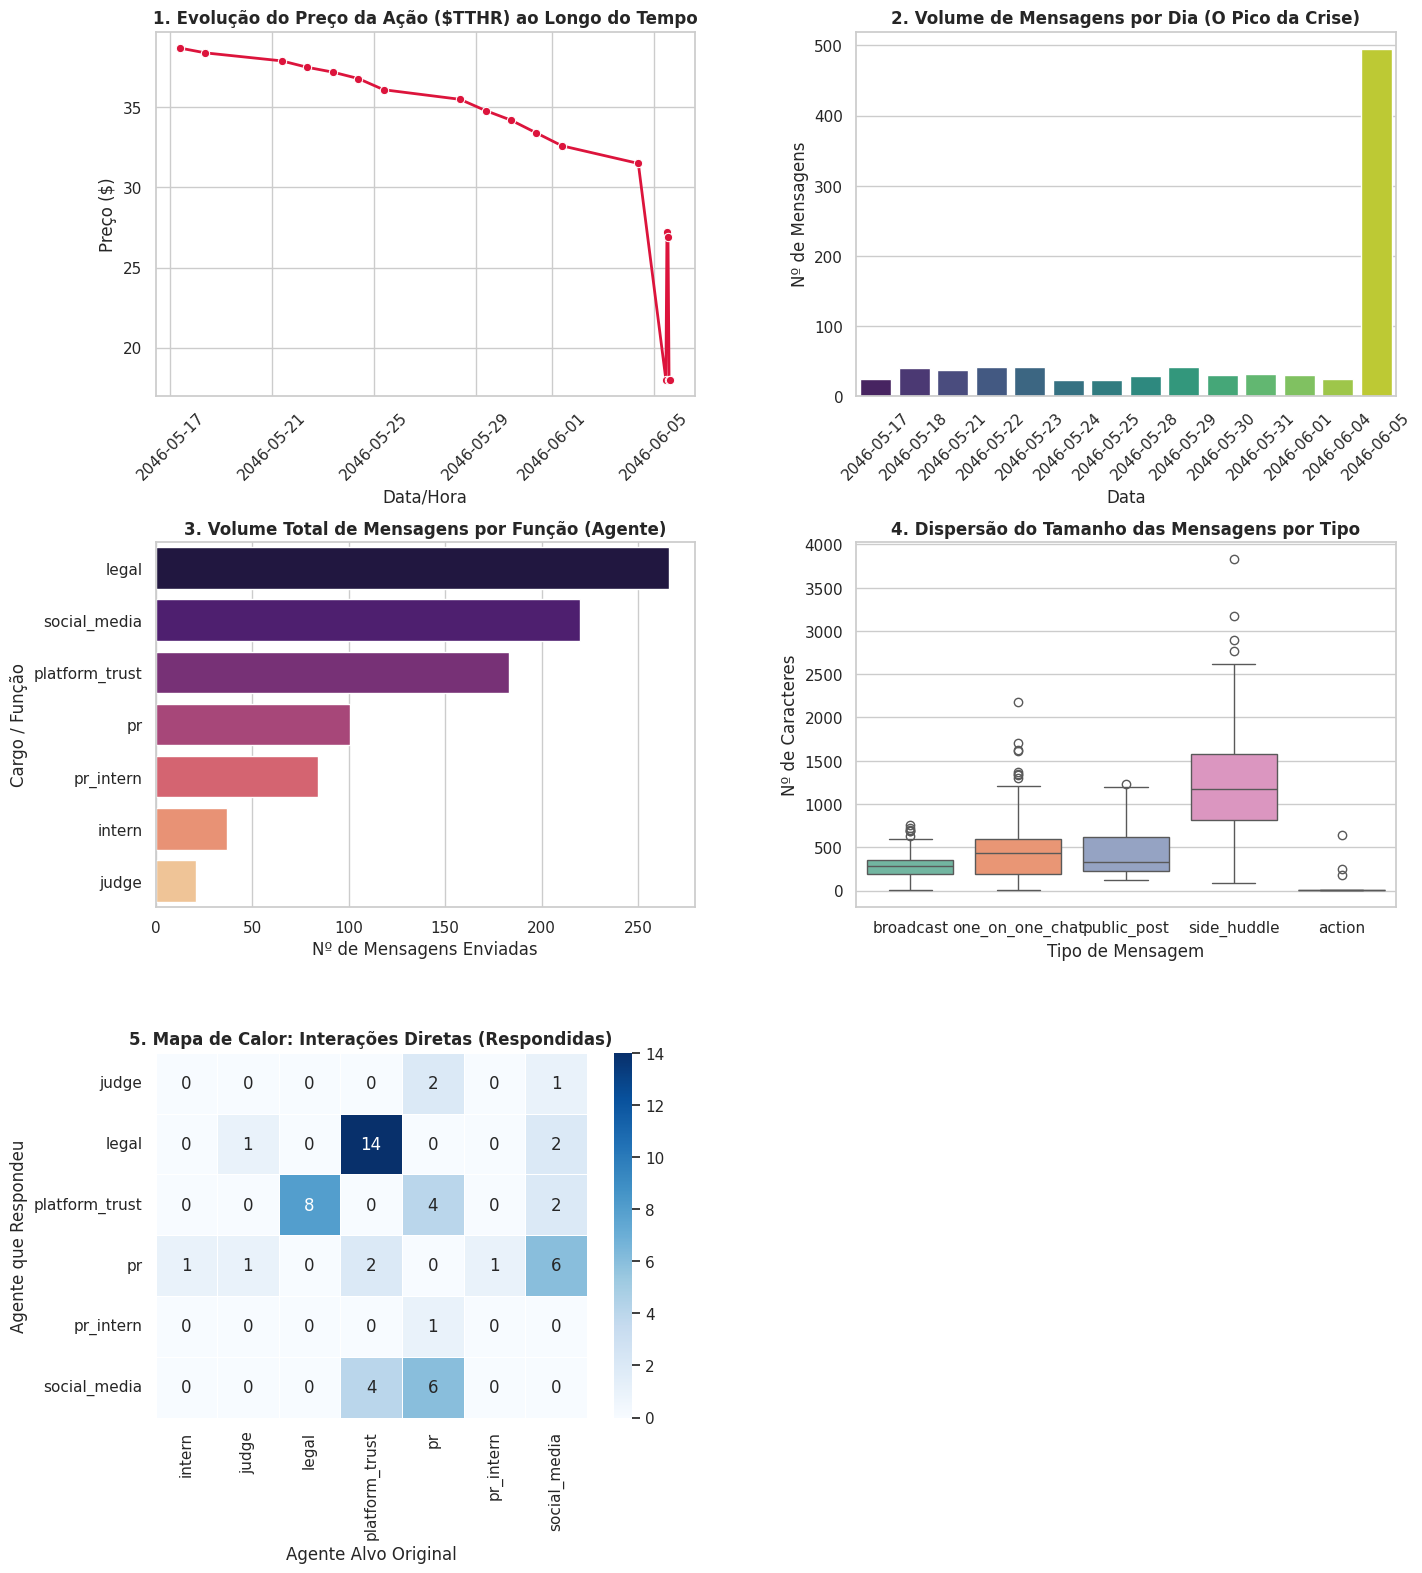

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Para evitar avisos visuais no notebook

# 1. Carregar Dados
df_rounds = pd.read_csv('data_rounds.csv')
df_messages = pd.read_csv('data_messages.csv')

# 2. Tratamento Prévio (Tipos de dados e Outliers)
df_rounds['hour'] = pd.to_datetime(df_rounds['hour'])
df_rounds['stock_price_num'] = df_rounds['stock_price'].astype(str).str.replace('$', '').astype(float)
df_rounds.loc[df_rounds['stock_price_num'] == 180.0, 'stock_price_num'] = 18.0 # Correção do Outlier

df_messages['timestamp'] = pd.to_datetime(df_messages['timestamp'])
df_messages['date'] = df_messages['timestamp'].dt.date

# Configuração de estilo geral para os gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- GRÁFICO 1: Gráfico de Linha (Evolução do Preço da Ação) ---
sns.lineplot(data=df_rounds, x='hour', y='stock_price_num', marker='o', ax=axes[0, 0], color='crimson', linewidth=2)
axes[0, 0].set_title('1. Evolução do Preço da Ação ($TTHR) ao Longo do Tempo', fontweight='bold')
axes[0, 0].set_ylabel('Preço ($)')
axes[0, 0].set_xlabel('Data/Hora')
axes[0, 0].tick_params(axis='x', rotation=45)

# --- GRÁFICO 2: Gráfico de Barras (Volume de Mensagens por Dia) ---
msg_por_dia = df_messages.groupby('date').size().reset_index(name='count')
sns.barplot(data=msg_por_dia, x='date', y='count', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('2. Volume de Mensagens por Dia (O Pico da Crise)', fontweight='bold')
axes[0, 1].set_ylabel('Nº de Mensagens')
axes[0, 1].set_xlabel('Data')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].savefig("mensagens_dia.jpeg")
# --- GRÁFICO 3: Gráfico de Barras (Atividade por Agente) ---
sns.countplot(data=df_messages, y='agent_role', order=df_messages['agent_role'].value_counts().index, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('3. Volume Total de Mensagens por Função (Agente)', fontweight='bold')
axes[1, 0].set_ylabel('Cargo / Função')
axes[1, 0].set_xlabel('Nº de Mensagens Enviadas')

# --- GRÁFICO 4: Boxplot (Comprimento das Mensagens vs Tipo de Canal) ---
# Adicionando uma coluna com o tamanho do texto (em caracteres)
df_messages['msg_length'] = df_messages['content'].astype(str).apply(len)
sns.boxplot(data=df_messages, x='message_type', y='msg_length', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('4. Dispersão do Tamanho das Mensagens por Tipo', fontweight='bold')
axes[1, 1].set_ylabel('Nº de Caracteres')
axes[1, 1].set_xlabel('Tipo de Mensagem')

# --- GRÁFICO 5: Mapa de Calor (Heatmap de Relações One-on-One) ---
df_1v1 = df_messages[df_messages['message_type'] == 'one_on_one_chat'].copy()
df_autores = df_messages[['message_id', 'agent_role']].rename(columns={'agent_role': 'target_role'})
df_conexoes = df_1v1.merge(df_autores, left_on='responding_to', right_on='message_id', how='inner')
interacoes = df_conexoes.groupby(['agent_role', 'target_role']).size().reset_index(name='quantidade')
matriz_interacao = interacoes.pivot(index='agent_role', columns='target_role', values='quantidade').fillna(0)

sns.heatmap(matriz_interacao, annot=True, fmt=".0f", cmap="Blues", linewidths=.5, ax=axes[2, 0])
axes[2, 0].set_title('5. Mapa de Calor: Interações Diretas (Respondidas)', fontweight='bold')
axes[2, 0].set_ylabel('Agente que Respondeu')
axes[2, 0].set_xlabel('Agente Alvo Original')

# Ocultar o último gráfico vazio (índice 2,1) pois só precisamos de 5
axes[2, 1].axis('off')

plt.show()

In [ ]:
import re

# 1. Carregar os dados
df_messages = pd.read_csv('data_messages.csv')

# =======================================================
# PARTE 1: DETECÇÃO DE EMOJIS, TEXTOS CORROMPIDOS E ANOMALIAS
# =======================================================
# A expressão '[^\x00-\x7F]+' busca qualquer coisa que não seja texto padrão ASCII.
# Isso inclui emojis, caracteres acentuados estranhos para inglês ou corrupção de arquivo.
def encontrar_estranhos(texto):
    texto = str(texto)
    encontrados = set(re.findall(r'[^\x00-\x7F]+', texto))
    return ', '.join(encontrados) if encontrados else None

df_messages['caracteres_estranhos'] = df_messages['content'].apply(encontrar_estranhos)
mensagens_anomalas = df_messages[df_messages['caracteres_estranhos'].notna()]

print("=== 1. QUALIDADE DO TEXTO (Emojis e Caracteres Estranhos) ===")
print(f"Total de mensagens com caracteres especiais/emojis: {len(mensagens_anomalas)}")
if not mensagens_anomalas.empty:
    # Exibe as colunas principais e o que foi encontrado de estranho
    print(mensagens_anomalas)



=== 2. ESTATÍSTICA DE COMPRIMENTO DAS MENSAGENS ===
Média geral do volume corporativo: 65.9 palavras por mensagem.



,agent_role,Total Mensagens,Média de Palavras,Mensagem Mais Longa (palavras),Mensagem Mais Curta (palavras)
6,social_media,220,81.8,508,1
2,legal,266,75.3,442,1
5,pr_intern,84,57.5,247,1
3,platform_trust,183,56.7,493,1
1,judge,21,56.1,118,1
4,pr,101,41.9,157,1
0,intern,37,40.6,136,1


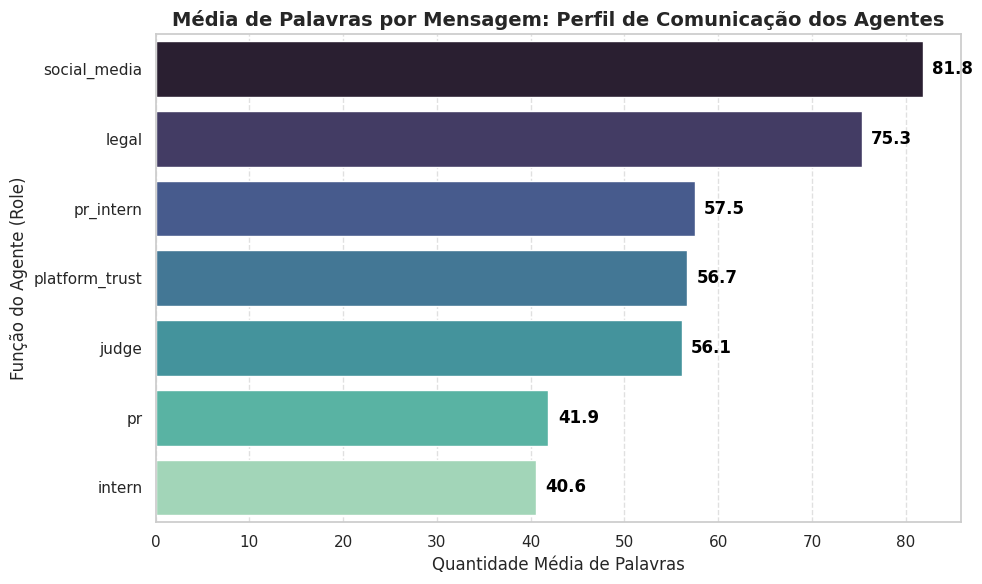

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df_messages = pd.read_csv('data_messages.csv')

# =======================================================
# PARTE 2: TABELA DE MÉDIA DE PALAVRAS (WORD COUNT)
# =======================================================
# Conta o número de palavras dividindo o texto pelos espaços
df_messages['word_count'] = df_messages['content'].astype(str).apply(lambda x: len(x.split()))

print("\n=== 2. ESTATÍSTICA DE COMPRIMENTO DAS MENSAGENS ===")
media_geral = df_messages['word_count'].mean()
print(f"Média geral do volume corporativo: {media_geral:.1f} palavras por mensagem.\n")

# Agrupa por agente para gerar a tabela resumo
tabela_palavras = df_messages.groupby('agent_role')['word_count'].agg(['count', 'mean', 'max', 'min']).reset_index()
tabela_palavras.rename(columns={
    'count': 'Total Mensagens', 
    'mean': 'Média de Palavras', 
    'max': 'Mensagem Mais Longa (palavras)', 
    'min': 'Mensagem Mais Curta (palavras)'
}, inplace=True)

# Arredondando a média para 1 casa decimal para ficar bonito na tabela
tabela_palavras['Média de Palavras'] = tabela_palavras['Média de Palavras'].round(1)

# Ordenando do agente que escreve mais para o que escreve menos
tabela_palavras = tabela_palavras.sort_values(by='Média de Palavras', ascending=False)
display(tabela_palavras)


# =======================================================
# PARTE 3: GRÁFICO DA MÉDIA DE PALAVRAS POR AGENTE
# =======================================================
plt.figure(figsize=(10, 6))

# Gráfico de barras horizontais usando Seaborn
sns.barplot(
    data=tabela_palavras, 
    x='Média de Palavras', 
    y='agent_role', 
    palette='mako'
)

plt.title('Média de Palavras por Mensagem: Perfil de Comunicação dos Agentes', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade Média de Palavras', fontsize=12)
plt.ylabel('Função do Agente (Role)', fontsize=12)

# Adicionando os valores exatos na ponta de cada barra para facilitar a leitura
for index, value in enumerate(tabela_palavras['Média de Palavras']):
    plt.text(value + 1, index, str(value), va='center', color='black', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("palavras_por_agente.jpeg")

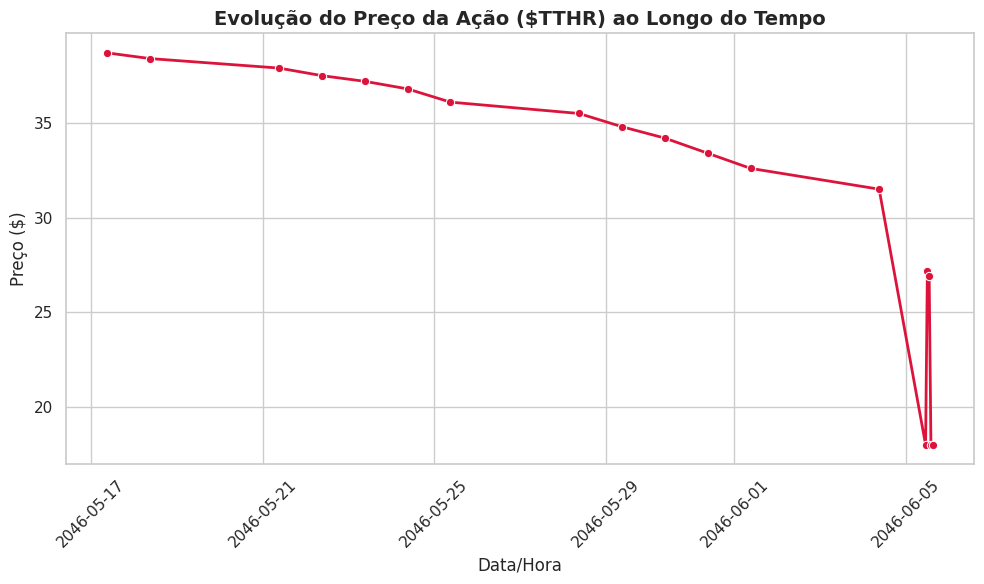

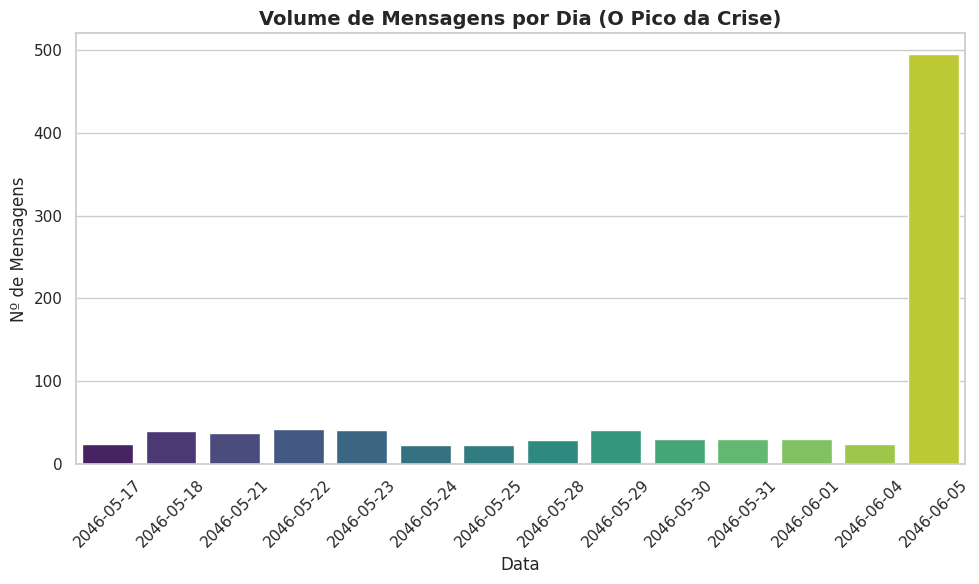

In [14]:
# ==========================================
# 1. SALVAR GRÁFICO DA AÇÃO (LINHA)
# ==========================================
plt.figure(figsize=(10, 6)) # Cria uma "tela" em branco só para ele

sns.lineplot(data=df_rounds, x='hour', y='stock_price_num', marker='o', color='crimson', linewidth=2)
plt.title('Evolução do Preço da Ação ($TTHR) ao Longo do Tempo', fontweight='bold', fontsize=14)
plt.ylabel('Preço ($)', fontsize=12)
plt.xlabel('Data/Hora', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout() # Ajusta as margens para não cortar nada
plt.savefig('grafico_01_preco_acao.png', dpi=300) # Salva a imagem
plt.show() # Exibe na tela e limpa a "tela" para o próximo gráfico


# ==========================================
# 2. SALVAR GRÁFICO DE VOLUME (BARRAS)
# ==========================================
plt.figure(figsize=(10, 6)) # Cria uma nova "tela" em branco

sns.barplot(data=msg_por_dia, x='date', y='count', palette='viridis')
plt.title('Volume de Mensagens por Dia (O Pico da Crise)', fontweight='bold', fontsize=14)
plt.ylabel('Nº de Mensagens', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('grafico_02_volume_mensagens.png', dpi=300)
plt.show()

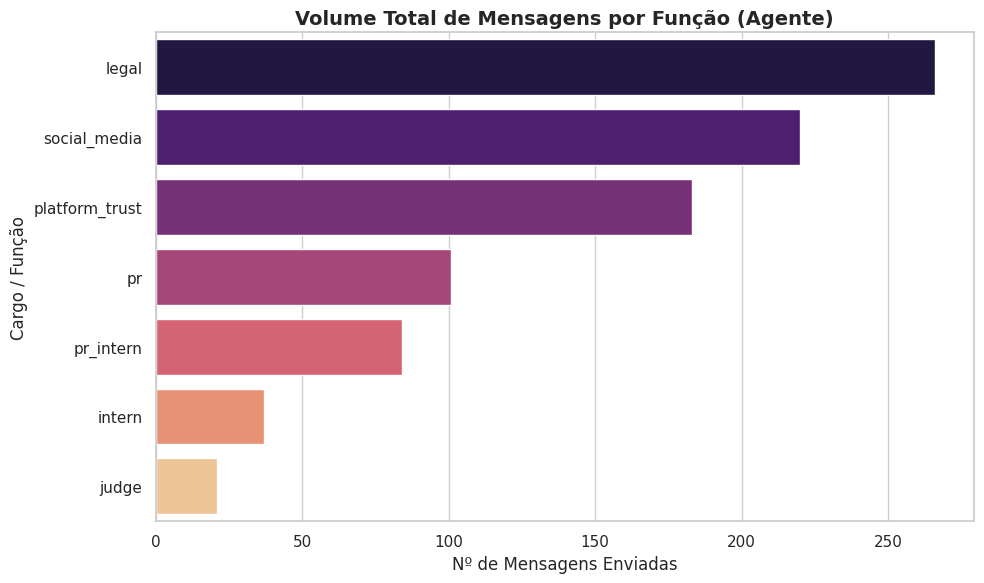

In [15]:
# ==========================================
# 3. SALVAR GRÁFICO DE ATIVIDADE POR AGENTE
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Cria uma "tela" em branco com um bom tamanho
plt.figure(figsize=(10, 6))

# Gera o gráfico de barras horizontais
sns.countplot(data=df_messages, y='agent_role', order=df_messages['agent_role'].value_counts().index, palette='magma')

# Adiciona título e rótulos
plt.title('Volume Total de Mensagens por Função (Agente)', fontweight='bold', fontsize=14)
plt.ylabel('Cargo / Função', fontsize=12)
plt.xlabel('Nº de Mensagens Enviadas', fontsize=12)

# Ajusta as margens para não cortar o texto
plt.tight_layout()

# Salva a imagem em alta resolução (300 dpi)
plt.savefig('grafico_03_atividade_agente.png', dpi=300)

# Exibe o gráfico na tela
plt.show()